# Task 1: Problem Identification

## Selected Problem Type - Image Classification

### Explanation
The dataset is organized into separate folders (dent, normal, scratch and stain) where each folder contains images belonging to a specific category. The goal is to train a CNN model to classify an input image into one of these predefined classes. This matches the definition of an image classification problem because:

1) Each image belongs to only one class.
2) No bounding boxes are provided (so it is not object detection).
3) No pixel level masks are available (so it is not semantic or instance segmentation).

Classes in dataset:  ['dent', 'normal', 'scratch', 'stain']
Number of classes:  4

Number of images per class: 
dent: 120 images
normal: 120 images
scratch: 120 images
stain: 120 images


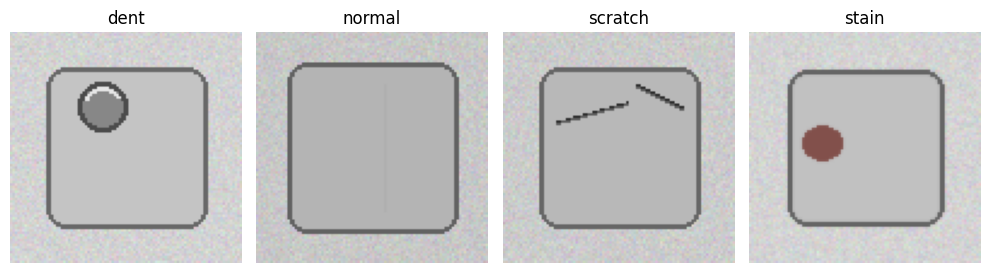


Image dimensions: 
dent: (96, 96)
normal: (96, 96)
scratch: (96, 96)
stain: (96, 96)

Dataset Balance Analysis: 
Dataset is balanced


In [35]:
# Task 2: Dataset Exploration

import os

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get class names
classes = [cls for cls in os.listdir("images") if not cls.startswith('.')]
print("Classes in dataset: ", classes)

# Number of classes
print("Number of classes: ", len(classes))

# Count images per class
print("\nNumber of images per class: ")
class_counts = {}

for cls in classes:
    class_path = os.path.join("images", cls)
    images = [img for img in os.listdir(class_path) if not cls.startswith('.')]
    class_counts[cls] = len(images)

    print(f"{cls}: {len(images)} images")

# Display sample images
plt.figure(figsize=(10,10))

for i, cls in enumerate(classes):
    class_path = os.path.join("images", cls)
    sample_image = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, sample_image)

    img = Image.open(img_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.savefig("results/sample_images.png")
plt.show()

# Image dimensions
print("\nImage dimensions: ")

for cls in classes:
    class_path = os.path.join("images", cls)
    sample_image = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, sample_image)

    img = Image.open(img_path)

    print(f"{cls}: {img.size}")


# Check if dataset have imbalance
print("\nDataset Balance Analysis: ")
max_count = max(class_counts.values())
min_count = min(class_counts.values())

if max_count - min_count > 10:
    print("Dataset is imbalanced")
else:
    print("Dataset is balanced")

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.



Batch Shape:  (32, 128, 128, 3)

Label Shape:  (32, 4)


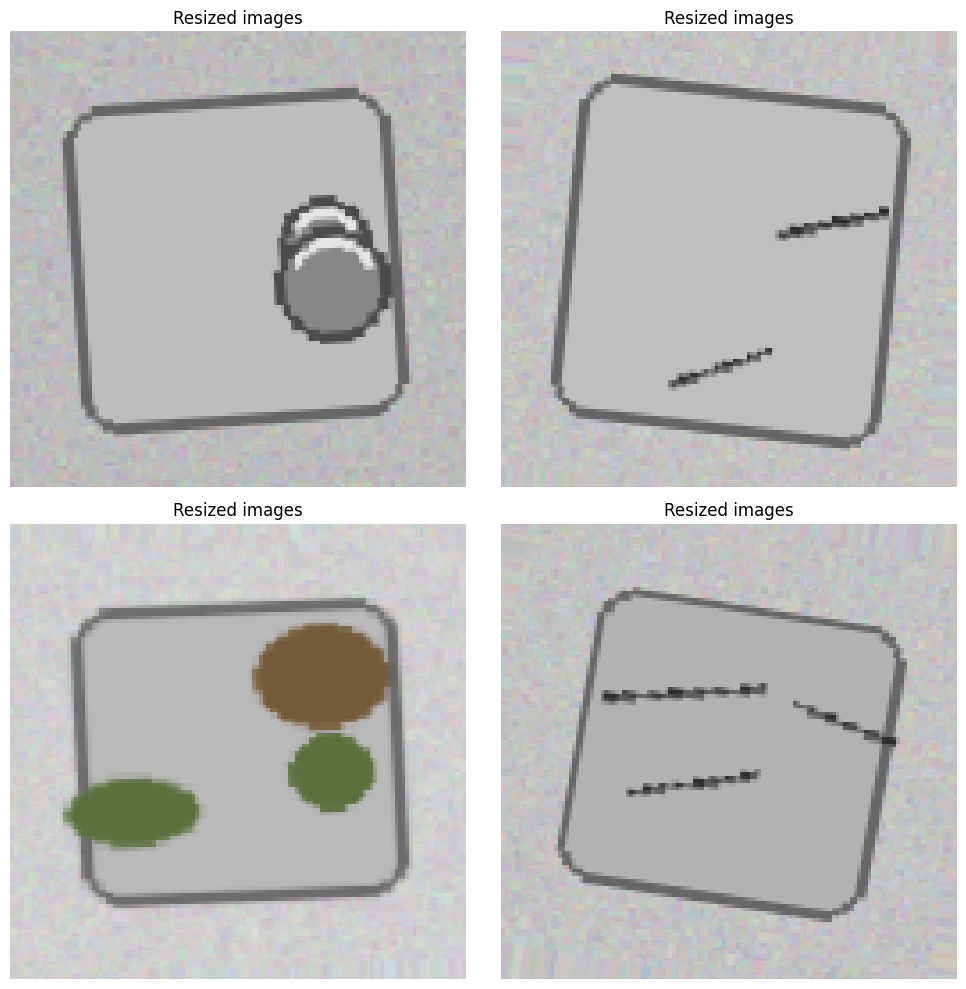

In [36]:
# Task 3: Image Preprocessing

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset Path
dataset_path = "images"

# Image Size
img_size = (128, 128)

# Batch Size
batch_size = 32

# Data Augmentation and Normalization
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2,
    rotation_range = 10,
    zoom_range = 0.1,
    horizontal_flip = True
)

# Training Data
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    subset = 'training'
)

# Validation data
val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    subset = 'validation'
)

# Display shape of one batch
images, labels = next(train_data)
print("\nBatch Shape: ", images.shape)
print("\nLabel Shape: ", labels.shape)

# Display resized images
plt.figure(figsize=(10, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i])
    plt.title("Resized images")
    plt.axis("off")

plt.tight_layout()
plt.savefig("results/resized_images.png")
plt.show()

In [37]:
# Task 4: CNN Model Creation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# CNN Model
model = Sequential([

    # First Convolution Layer
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(128, 128, 3)
    ),

    # First Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Layer
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),
    
    # Second Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Third Convolution Layer
    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),
    
    # Third Pooling Layer
    MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    Flatten(),

    # Dense Layer
    Dense(128, activation='relu'),

    # Dropout Layer
    Dropout(0.5),

    # Output Layer
    Dense(4, activation='softmax')
])

# Compile model
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = [
        'accuracy',
        tf.keras.metrics.Precision(name = 'precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()

C:\Users\294874\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 574ms/step - accuracy: 0.2708 - loss: 1.6569 - precision: 0.2034 - recall: 0.0312 - val_accuracy: 0.2500 - val_loss: 1.3848 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 493ms/step - accuracy: 0.2396 - loss: 1.3853 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.3542 - val_loss: 1.3734 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 536ms/step - accuracy: 0.3281 - loss: 1.3605 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.5312 - val_loss: 1.3151 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 648ms/step - accuracy: 0.4062 - loss: 1.2827 - precision: 0.3889 - recall: 0.0182 - val_accuracy: 0.5833 - val_loss: 1.1262 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 505ms/step - accuracy: 0.5391 - loss: 1.0216 - precision: 0.7131 - reca

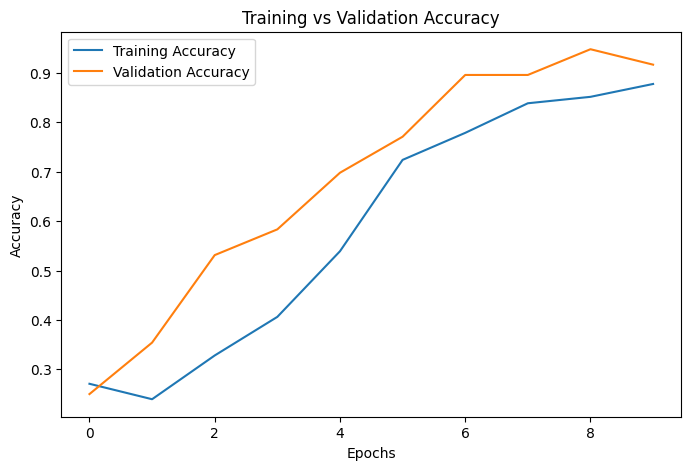

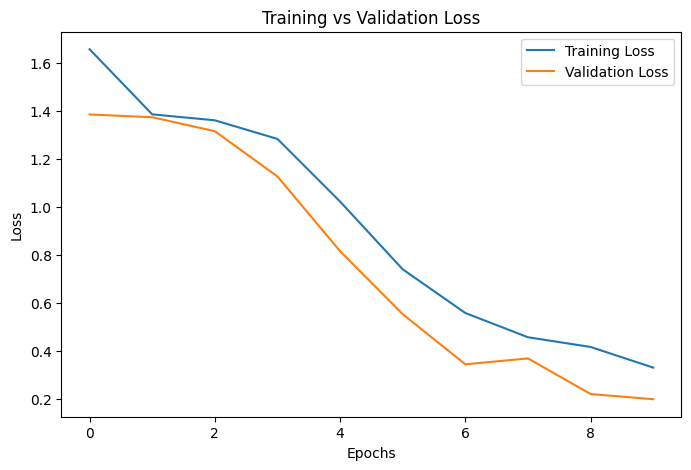

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 487ms/step - accuracy: 0.9167 - loss: 0.1985 - precision: 0.9167 - recall: 0.9167

Test Accuracy:  0.9166666865348816
Test Loss:  0.19854934513568878
Precision:  0.9166666865348816
Recall:  0.9166666865348816
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step


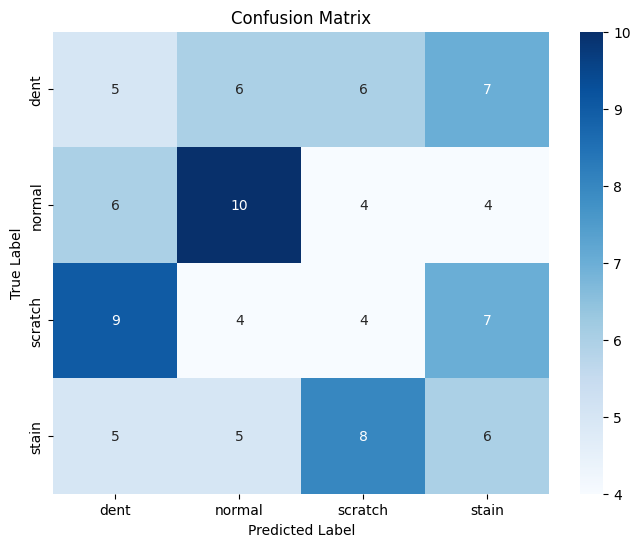


Classification Report: 

              precision    recall  f1-score   support

        dent       0.20      0.21      0.20        24
      normal       0.40      0.42      0.41        24
     scratch       0.18      0.17      0.17        24
       stain       0.25      0.25      0.25        24

    accuracy                           0.26        96
   macro avg       0.26      0.26      0.26        96
weighted avg       0.26      0.26      0.26        96

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


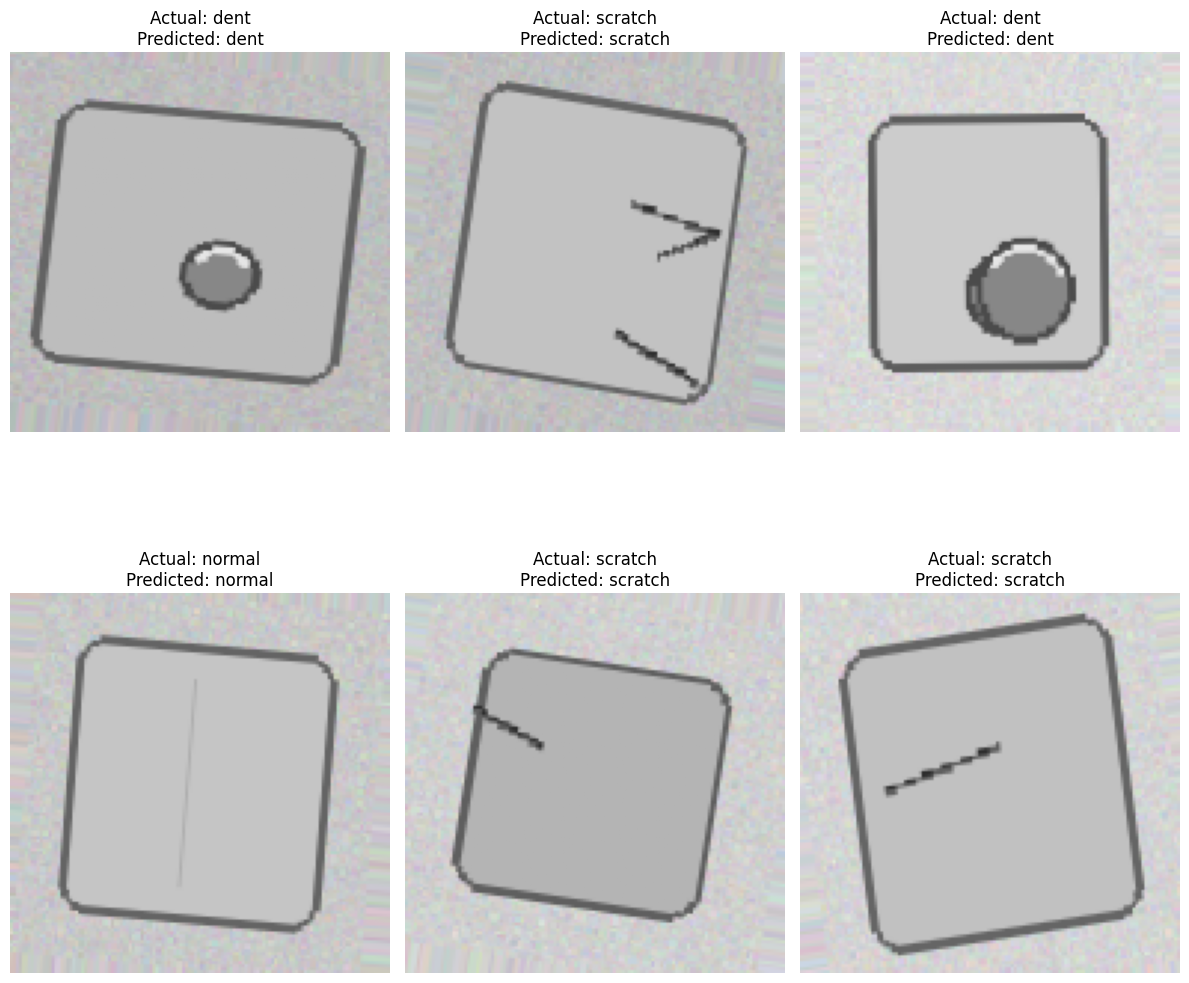

In [38]:
# Task 5: Model Training and Evaluation

# Train the CNN Model
history = model.fit(
    train_data,
    validation_data = val_data,
    epochs = 10
)

# Display training and validation accuracy/loss

# Accuracy plot
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig("results/accuracy_loss_curves.png")
plt.show()


# Testing Performance
test_loss, test_accuracy, precision, recall = model.evaluate(val_data)

print("\nTest Accuracy: ", test_accuracy)
print("Test Loss: ", test_loss)
print("Precision: ", precision)
print("Recall: ", recall)

# Confusion Matrix
predictions = model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_data.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=val_data.class_indices.keys(),
    yticklabels=val_data.class_indices.keys()
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig("results/confusion_matrix.png")
plt.show()

# Classification Report
print("\nClassification Report: \n")
print(classification_report(
    true_classes, predicted_classes, target_names=val_data.class_indices.keys()
))

# Display sample predicitons
images, labels = next(val_data)
predictions = model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)
class_names = list(val_data.class_indices.keys())

plt.figure(figsize=(12, 12))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    actual_label = class_names[np.argmax(labels[i])]
    predicted_label = class_names[predicted_labels[i]]

    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("sample_predictions/prediction_outputs.png")
plt.show()